# **Global Correlation Analysis Across Socioeconomic Domains** 👨‍💻💻🗺️

This notebook loads, cleans, organizes and visualize three datasets:
- Global_Weather_Repository.csv
- Literacy_Rate.xlsx
- World_Data_2023.csv

Then explores cross-domain relationships using worldwide indicators spanning six key dimensions:

- **Economy**
- **Health**
- **Education**
- **Demography**
- **Environment**
- **Geopolitics**

The objective is to identify structural patterns, quantify relationships between indicators, and understand how different aspects of national development interact with one another. The analysis leverages:


- Domain-based variable grouping
- Pairwise correlation computation
- Annotated heatmaps for interpretability
- Comparative evaluation across 15 domain combinations

This document serves as the analytical foundation for broader insights summarized in the project’s README.


Below you will find the methodology, transformations, and visual correlation outputs that support the final conclusions.

In [1]:
import pandas as pd
import numpy as np


### Load datasets

In [2]:
weather = pd.read_csv('Global_Weather_Repository.csv')
literacy = pd.read_excel('Literacy_Rate.xlsx')
world = pd.read_csv('World_Data_2023.csv', sep=';')

In [3]:
df = pd.read_csv('World_Data_2023.csv', sep=';')
df.to_csv('World_Data_2023_corrected.csv', index=False)

In [4]:
world = pd.read_csv('World_Data_2023_corrected.csv')

### Initial inspection

In [5]:

weather.head(), literacy.head(), world.head()


(       country     location_name  latitude  longitude        timezone  \
 0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
 1      Albania            Tirana     41.33      19.82   Europe/Tirane   
 2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
 3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
 4       Angola            Luanda     -8.84      13.23   Africa/Luanda   
 
    last_updated_epoch      last_updated  temperature_celsius  \
 0          1715849100  2024-05-16 13:15                 26.6   
 1          1715849100  2024-05-16 10:45                 19.0   
 2          1715849100  2024-05-16 09:45                 23.0   
 3          1715849100  2024-05-16 10:45                  6.3   
 4          1715849100  2024-05-16 09:45                 26.0   
 
    temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
 0                    79.8  Partly Cloudy  ...                8.4   
 1                    66

### Standardize column names

In [6]:

def clean_columns(df):
    df.columns = (
        df.columns.str.lower()
        .str.strip()
        .str.replace(' ', '_')
        .str.replace('[^a-z0-9_]', '', regex=True)
    )
    return df

weather = clean_columns(weather)
literacy = clean_columns(literacy)
world = clean_columns(world)


### Handle missing values

In [7]:

weather = weather.dropna(how='all')
literacy = literacy.dropna(how='all')
world = world.dropna(how='all')

weather = weather.fillna(method='ffill')
literacy = literacy.fillna(method='ffill')
world = world.fillna(method='ffill')


C:\Users\User\AppData\Local\Temp\ipykernel_12948\2570131581.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather = weather.fillna(method='ffill')
C:\Users\User\AppData\Local\Temp\ipykernel_12948\2570131581.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  literacy = literacy.fillna(method='ffill')
C:\Users\User\AppData\Local\Temp\ipykernel_12948\2570131581.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  world = world.fillna(method='ffill')


### Sort tables

In [8]:

if 'country' in weather.columns:
    weather = weather.sort_values(by='country')

if 'country' in literacy.columns:
    literacy = literacy.sort_values(by='country')

if 'country' in world.columns:
    world = world.sort_values(by='country')


### Final structure

In [9]:

weather.info(), literacy.info(), world.info()


<class 'pandas.core.frame.DataFrame'>
Index: 27367 entries, 0 to 11592
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       27367 non-null  object 
 1   location_name                 27367 non-null  object 
 2   latitude                      27367 non-null  float64
 3   longitude                     27367 non-null  float64
 4   timezone                      27367 non-null  object 
 5   last_updated_epoch            27367 non-null  int64  
 6   last_updated                  27367 non-null  object 
 7   temperature_celsius           27367 non-null  float64
 8   temperature_fahrenheit        27367 non-null  float64
 9   condition_text                27367 non-null  object 
 10  wind_mph                      27367 non-null  float64
 11  wind_kph                      27367 non-null  float64
 12  wind_degree                   27367 non-null  int64  
 13  wind_d

(None, None, None)

# Clear the other tables

In [10]:
weather, literacy

(           country  location_name  latitude  longitude           timezone  \
 0      Afghanistan          Kabul     34.52      69.18         Asia/Kabul   
 15668  Afghanistan          Kabul     34.52      69.18         Asia/Kabul   
 3700   Afghanistan          Kabul     34.52      69.18         Asia/Kabul   
 26197  Afghanistan          Kabul     34.52      69.18         Asia/Kabul   
 14303  Afghanistan          Kabul     34.52      69.18         Asia/Kabul   
 ...            ...            ...       ...        ...                ...   
 11504    Гватемала  New Guatemala     14.62     -90.53  America/Guatemala   
 11526       Польша         Beirut     51.12      17.53      Europe/Warsaw   
 11547       Турция          Yaren     39.55      27.62    Europe/Istanbul   
 11484     كولومبيا     Costa Rica      6.43     -70.92     America/Bogota   
 11592           火鸡       -Kingdom     38.85      34.65    Europe/Istanbul   
 
        last_updated_epoch      last_updated  temperature_cels

### Weather table columns

I took these only three columns (country, temperature(°C), Air quality US EPA Index) for the analysis

In [11]:
weather.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_carbon_monoxide',
       'air_quality_ozone', 'air_quality_nitrogen_dioxide',
       'air_quality_sulphur_dioxide', 'air_quality_pm25', 'air_quality_pm10',
       'air_quality_usepaindex', 'air_quality_gbdefraindex', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

### Aggregate the weather table 
[T°C]       ---> Arithmetic  mean (dispersed values)
[US EPA]    ---> Mode (1 to 5 Index)

In [12]:
weather2 = weather[["country","temperature_celsius","air_quality_usepaindex"]].groupby("country").agg(
    {
        "temperature_celsius": "mean",
        "air_quality_usepaindex": lambda x : x.mode()[0]
    }
).reset_index()

### Check if the US EPA Index values are integer in every row 

In [13]:
weather2 = weather2.round(2)

integers = weather2["air_quality_usepaindex"]%1 == 0
integers.all()

np.True_

### Check if any country appears more than once in the table

This way we avoid cases where we have two values that are repeated in pairs
>Example: [1,2,2,1]
>>In this case the mode will be 1 and 2, generating a duplicate in the register

In [14]:
countries = weather2["country"]

repeats = set()

repetidos = set(x for x in countries if x in repeats or repeats.add(x))
print(list(repetidos))

[]


### Do the same with the Literacy_rate.xlsx

In [15]:
literacy

,sno,country,literacy_rate,year
169,170,Afghanistan,0.37,2021.0
30,31,Albania,0.99,2022.0
128,129,Algeria,0.81,2018.0
66,67,American Samoa,0.97,1980.0
0,1,Andorra,1.00,2016.0
...,...,...,...,...
82,83,Vietnam,0.96,2019.0
148,149,Yemen,0.70,2015.0
118,119,Zambia,0.88,2020.0
109,110,Zimbabwe,0.90,2022.0


In [16]:
literacy2 = literacy[["country","literacy_rate"]].groupby("country").agg(
    {
        "literacy_rate":"mean"
    }
).reset_index()

literacy2

,country,literacy_rate
0,Afghanistan,0.37
1,Albania,0.99
2,Algeria,0.81
3,American Samoa,0.97
4,Andorra,1.00
...,...,...
169,Venezuela,0.98
170,Vietnam,0.96
171,Yemen,0.70
172,Zambia,0.88


### Combine the data of the 3 tables using left joins using country column as the Primary Key

In [17]:
worldwide_data = world.merge(weather2, how="left", on="country")
worldwide_data = worldwide_data.merge(literacy2, how="left", on="country")

worldwide_data

,country,densitypkm2,abbreviation,agricultural_land_,land_areakm2,armed_forces_size,birth_rate,calling_code,capitalmajor_city,co2emissions,...,population_labor_force_participation_,tax_revenue_,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,temperature_celsius,air_quality_usepaindex,literacy_rate
0,Afghanistan,60.0,AF,"58,10%",652.230,323.000,"32,49",93.0,Kabul,8.672,...,"48,90%","9,30%","71,40%","11,12%",9.797.273,33.939110,67.709953,27.86,1.0,0.37
1,Albania,105.0,AL,"43,10%",28.748,9.000,"11,78",355.0,Tirana,4.536,...,"55,70%","18,60%","36,60%","12,33%",1.747.593,41.153332,20.168331,30.95,1.0,0.99
2,Algeria,18.0,DZ,"17,40%",2.381.741,317.000,"24,28",213.0,Algiers,150.006,...,"41,20%","37,20%","66,10%","11,70%",31.510.100,28.033886,1.659626,29.00,1.0,0.81
3,Andorra,164.0,AD,"40,00%",468,317.000,"7,2",376.0,Andorra la Vella,469,...,"41,20%","37,20%","66,10%","11,70%",67.873,42.506285,1.521801,18.76,1.0,1.00
4,Angola,26.0,AO,"47,50%",1.246.700,117.000,"40,73",244.0,Luanda,34.693,...,"77,50%","9,20%","49,10%","6,89%",21.061.025,-11.202692,17.873887,25.83,2.0,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32.0,VE,"24,50%",912.050,343.000,"17,88",58.0,Caracas,164.175,...,"59,70%","17,80%","73,30%","8,80%",25.162.368,6.423750,-66.589730,26.19,1.0,0.98
191,Vietnam,314.0,VN,"39,30%",331.210,522.000,"16,75",84.0,Hanoi,192.668,...,"77,40%","19,10%","37,60%","2,01%",35.332.140,14.058324,108.277199,27.93,1.0,0.96
192,Yemen,56.0,YE,"44,60%",527.968,40.000,"30,45",967.0,Sanaa,10.609,...,"38,00%","19,10%","26,60%","12,91%",10.869.523,15.552727,48.516388,25.24,2.0,0.70
193,Zambia,25.0,ZM,"32,10%",752.618,16.000,"36,19",260.0,Lusaka,5.141,...,"74,60%","16,20%","15,60%","11,43%",7.871.713,-13.133897,27.849332,27.05,1.0,0.88


# Correlational Analysis 

In [22]:
# Function to convert european numeric format to float
def fix_numeric(col):
    s = col.astype(str)
    s = s.str.replace(r"[^\d,.\-]", "", regex=True)                                           # Remove everything except digits, decimal separators, and minus sign
    s = s.str.replace(",", ".", regex=False)                                                  # Convert comma decimal format ("1,23") into dot decimal ("1.23")
    s = s.replace(["", ".", "nan", "NaN", "None"], np.nan).infer_objects(copy=False)          # Replace invalid residues with NaN

    return s.astype(float)                                                                    # Convert to float

### Verify that the values ​​in a column contain at least 60% numeric characters.

In [ ]:
def fix_numeric(col):
    s = col.astype(str)

    # remove all non-numeric symbols except dot, comma, minus
    s = s.str.replace(r"[^\d\.,\-]", "", regex=True)

    # If the value contains multiple dots → treat them as thousand separators (GDP case)
    def clean(x):
        if x.count('.') > 1:
            # remove dots (thousands)
            x = x.replace(".", "")
            # convert comma decimal to dot
            x = x.replace(",", ".")
            return x

        # If exactly one dot AND one comma, commas are thousand separators
        if x.count('.') == 1 and x.count(',') == 1:
            # Detect the decimal separator: it's the last symbol
            if x.rfind(',') > x.rfind('.'):
                # '1.234,56' → remove dots, convert last comma to decimal
                x = x.replace(".", "").replace(",", ".")
            else:
                # '1,234.56' → remove commas
                x = x.replace(",", "")
            return x

        # If only commas exist → comma is decimal
        if x.count(',') == 1 and x.count('.') == 0:
            x = x.replace(",", ".")
            return x

        # If only dots exist → assume either decimal or thousand
        # But if the dot is followed by exactly 3 digits in most cases → thousand
        if x.count('.') == 1:
            parts = x.split('.')
            if len(parts[-1]) == 3:    # e.g., "652.230"
                x = x.replace(".", "")
                return x

        return x

    s = s.map(clean)

    # Replace invalid or empty values
    s = s.replace(["", ".", "-", "..", ",", "--"], np.nan)

    return s.astype(float)

### Convert the verified columns to float applying the function numeric_like

In [48]:
object_cols = worldwide_data.select_dtypes(include=["object"]).columns

numeric_like = [
    col for col in object_cols
    if worldwide_data[col].astype(str).str.match(r"^[0-9\.,\-\$% ]+$", na=False).mean() > 0.6
]

for col in numeric_like:
    worldwide_data[col] = fix_numeric(worldwide_data[col])

### Categorizing the Worldwide_data in categories for facilitate analysis

In [50]:
categories = {
    "Economy": [
        "gdp", "tax_revenue_", "total_tax_rate", "minimum_wage",
        "population_labor_force_participation_", "unemployment_rate",
        "cpi", "cpi_change_"
    ],
    "Health": [
        "out_of_pocket_health_expenditure",
        "maternal_mortality_ratio",
        "infant_mortality",
        "life_expectancy",
        "physicians_per_thousand"
    ],
    "Education": [
        "gross_primary_education_enrollment_",
        "gross_tertiary_education_enrollment_",
        "literacy_rate"
    ],
    "Demography": [
        "densitypkm2",
        "population",
        "birth_rate",
        "fertility_rate",
        "urban_population"
    ],
    "Environment": [
        "agricultural_land_",
        "forested_area_",
        "co2emissions",
        "gasoline_price",
        "temperature_celsius",
        "air_quality_usepaindex"
    ],
    "Geopolitics": [
        "land_areakm2",
        "armed_forces_size"
    ]
}


### Computes the cross-correlation matrix between two predefined numeric column groups

In [53]:
def correlate_groups(df, group1, group2):
    cols1 = categories[group1]
    cols2 = categories[group2]
    
    # Select only numeric columns
    cols1 = [c for c in cols1 if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    cols2 = [c for c in cols2 if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    
    return df[cols1 + cols2].corr().loc[cols1, cols2]


In [54]:
import matplotlib.pyplot as plt
import itertools

### Computes and stores pairwise correlation matrices between all category combinations

In [55]:
pairwise_corr = {}

for g1, g2 in itertools.combinations(categories.keys(), 2):
    pairwise_corr[(g1, g2)] = correlate_groups(worldwide_data, g1, g2)


### In this way we can check the correlation in all categories one by one, but **let's go one step further** 👨‍🔬

In [56]:
pairwise_corr[("Economy", "Health")]

,out_of_pocket_health_expenditure,maternal_mortality_ratio,infant_mortality,life_expectancy,physicians_per_thousand
gdp,-0.095173,-0.119659,-0.150923,0.175928,0.089450
tax_revenue_,-0.329051,-0.327469,-0.353023,0.335525,0.262176
total_tax_rate,0.238816,0.213668,0.214594,-0.173666,-0.112236
minimum_wage,-0.294196,-0.344234,-0.417035,0.492666,0.437083
population_labor_force_participation_,-0.111525,0.188181,0.142206,-0.165332,-0.168470
unemployment_rate,0.024069,-0.018295,0.002786,-0.024095,-0.011483
cpi,0.159332,-0.008943,0.182116,-0.174870,-0.020665
cpi_change_,0.137353,0.014225,0.154477,-0.146294,-0.020327


### Plots a annotated heatmap showing correlation values between variables.

In [57]:
def plot_heatmap(matrix, title):
    plt.figure(figsize=(10, 6))
    plt.imshow(matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=90)
    plt.yticks(range(len(matrix.index)), matrix.index)

    # Enter the numerical values ​​in each cell.
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            value = matrix.iloc[i, j]
            plt.text(j, i, f"{value:.2f}",
                     ha='center', va='center', fontsize=8, color='black')

    plt.title(title)
    plt.tight_layout()
    plt.show()


=== HEATMAP: Economy vs Health ===


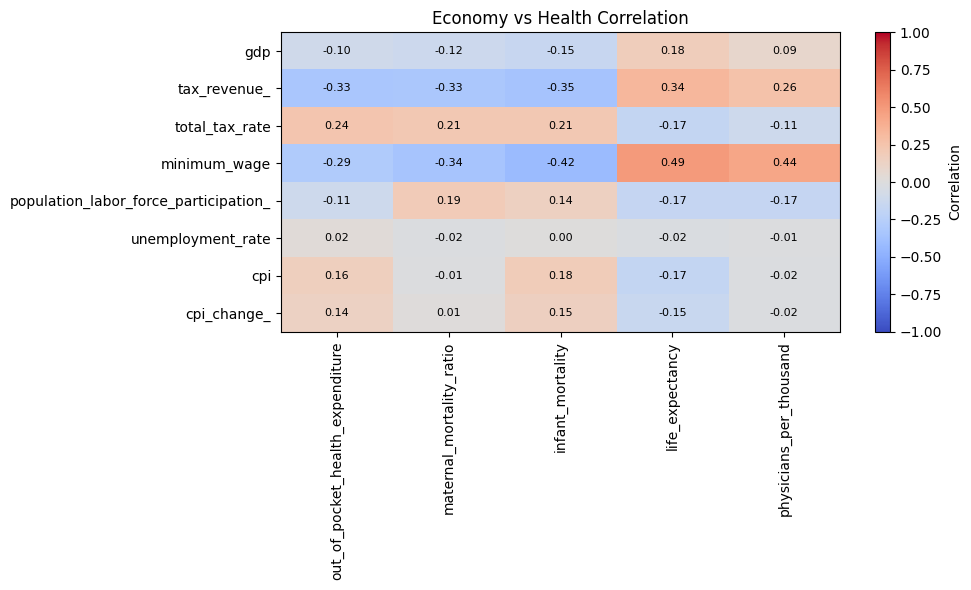


=== HEATMAP: Economy vs Education ===


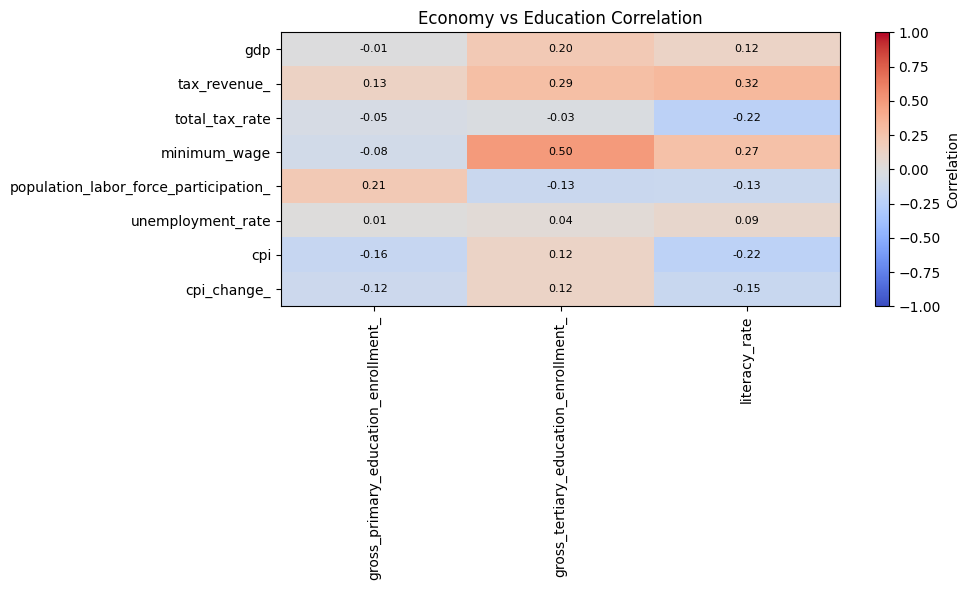


=== HEATMAP: Economy vs Demography ===


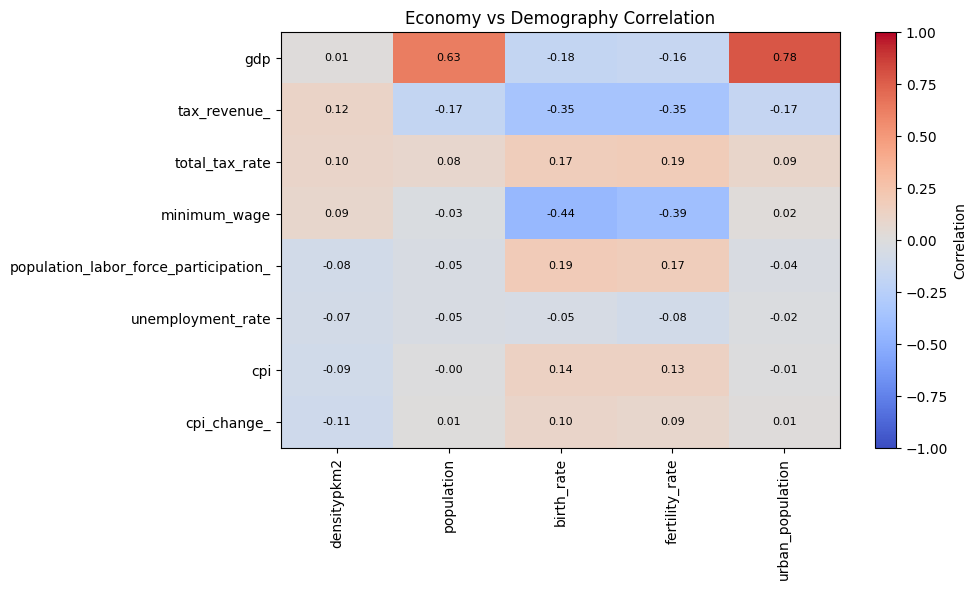


=== HEATMAP: Economy vs Environment ===


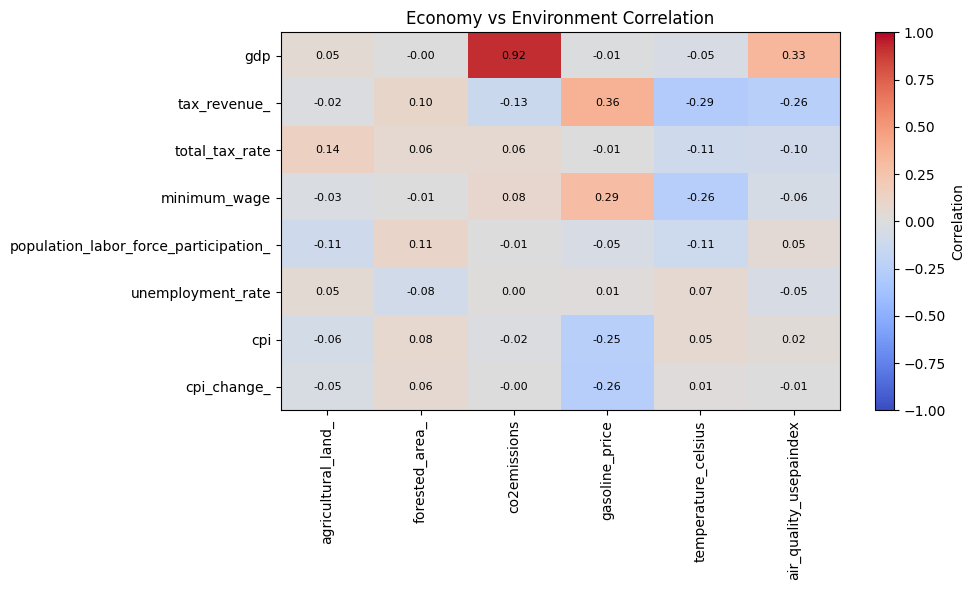


=== HEATMAP: Economy vs Geopolitics ===


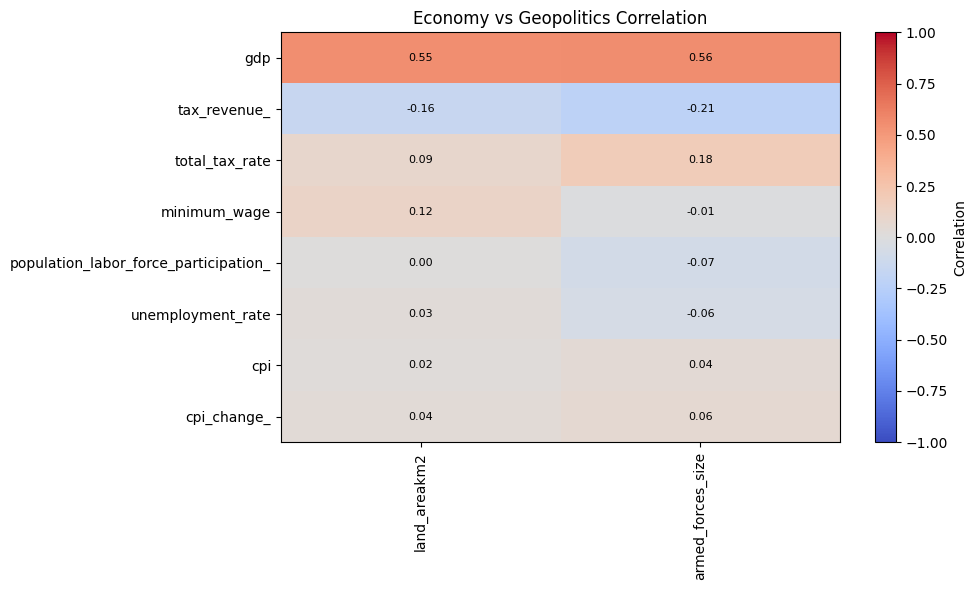


=== HEATMAP: Health vs Education ===


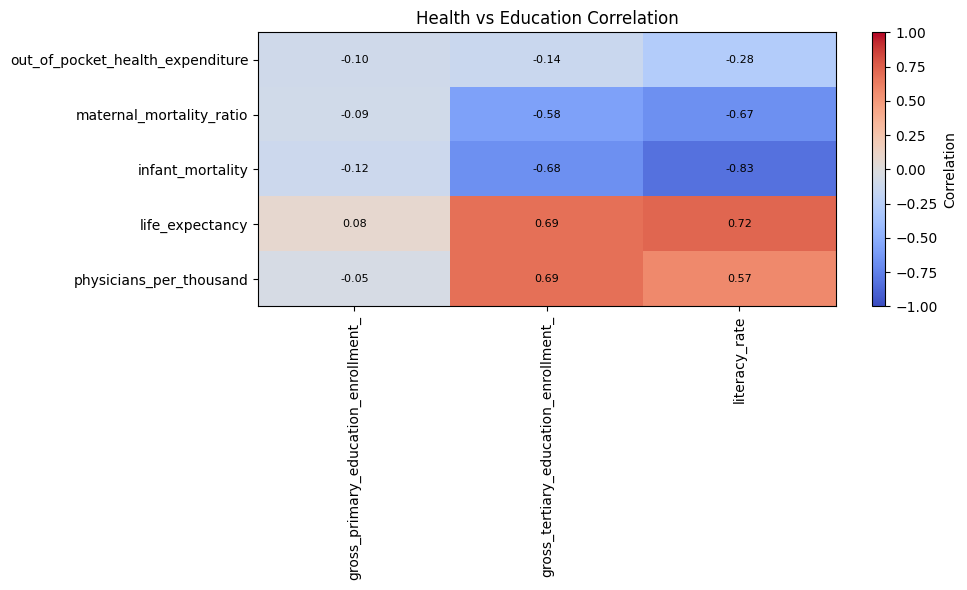


=== HEATMAP: Health vs Demography ===


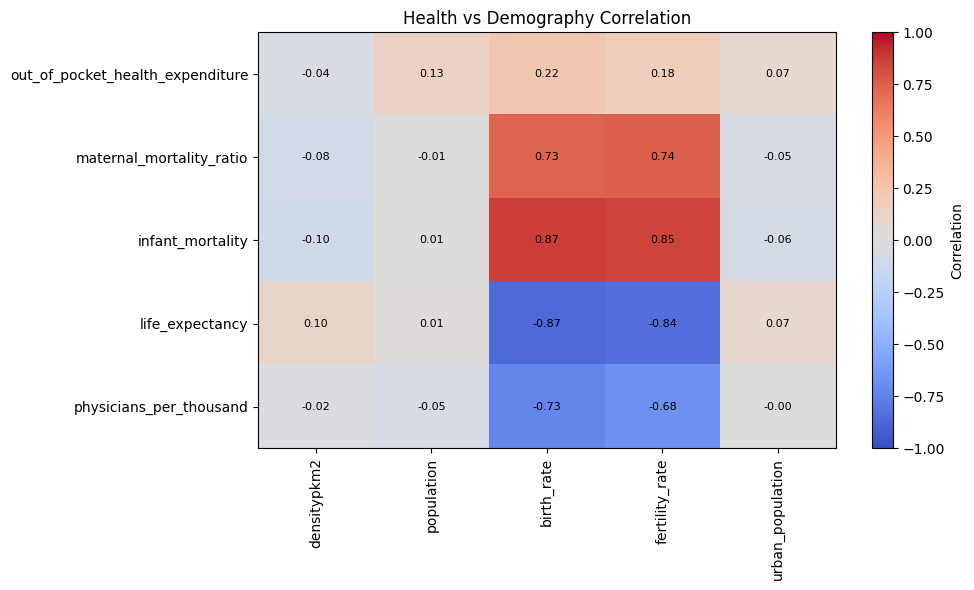


=== HEATMAP: Health vs Environment ===


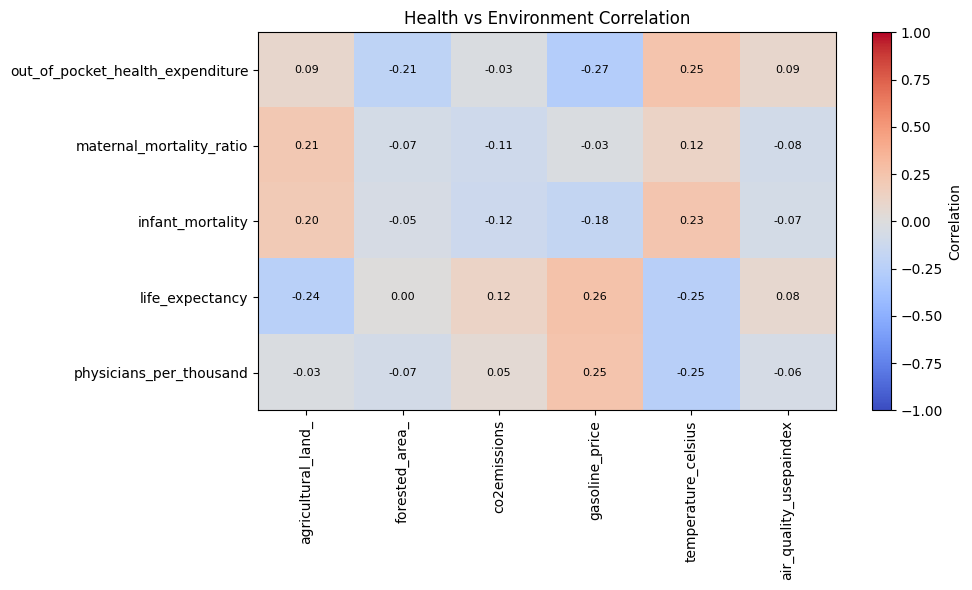


=== HEATMAP: Health vs Geopolitics ===


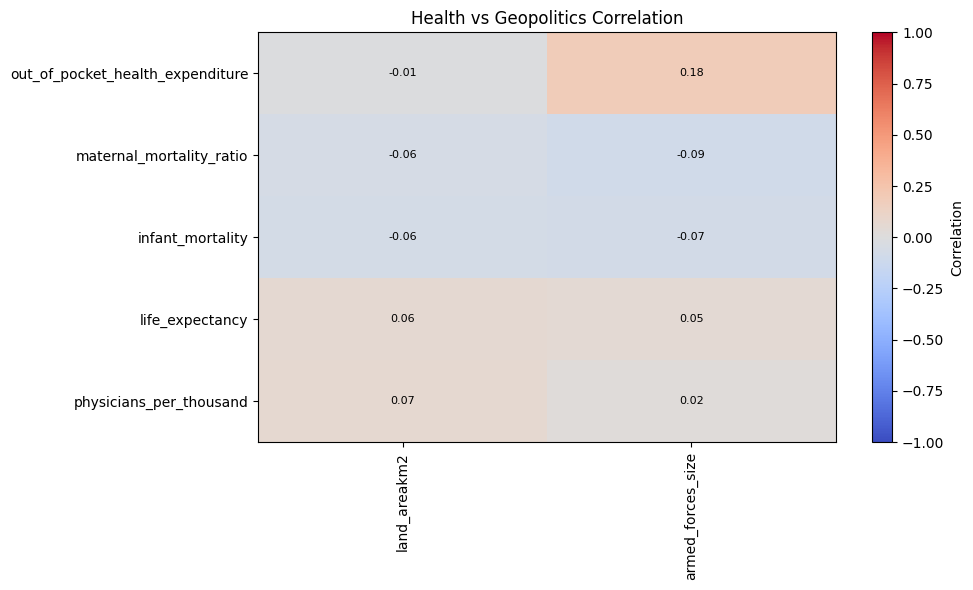


=== HEATMAP: Education vs Demography ===


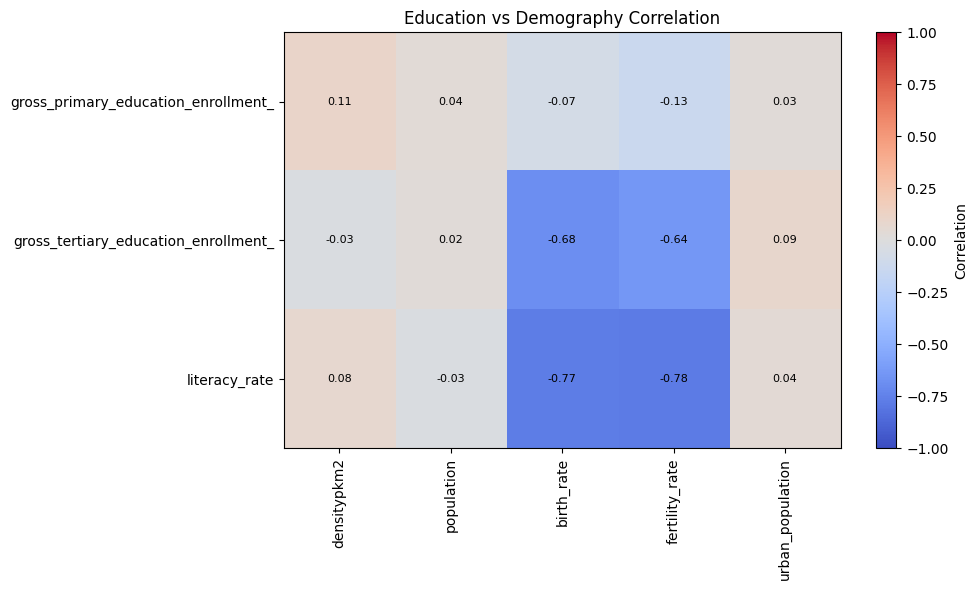


=== HEATMAP: Education vs Environment ===


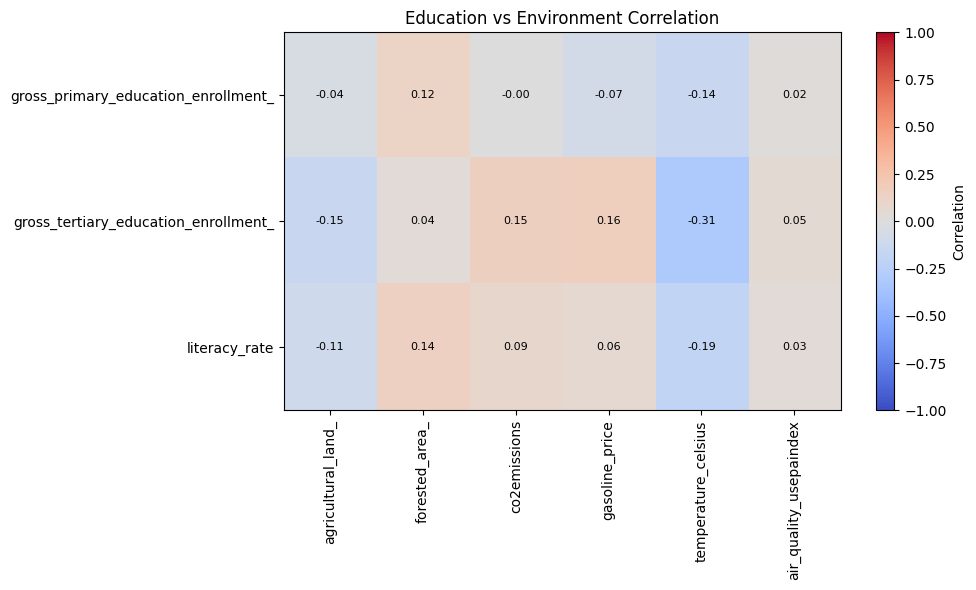


=== HEATMAP: Education vs Geopolitics ===


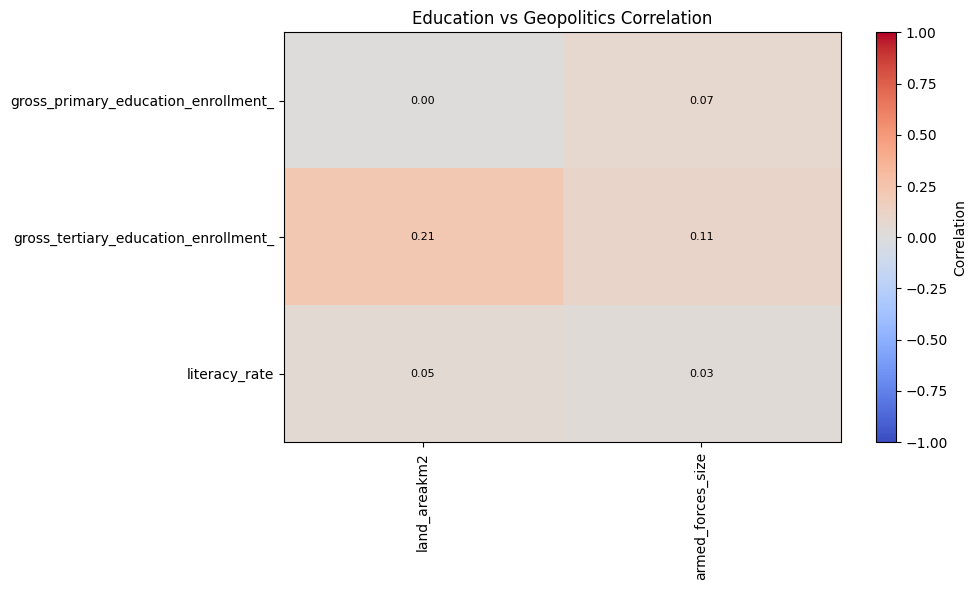


=== HEATMAP: Demography vs Environment ===


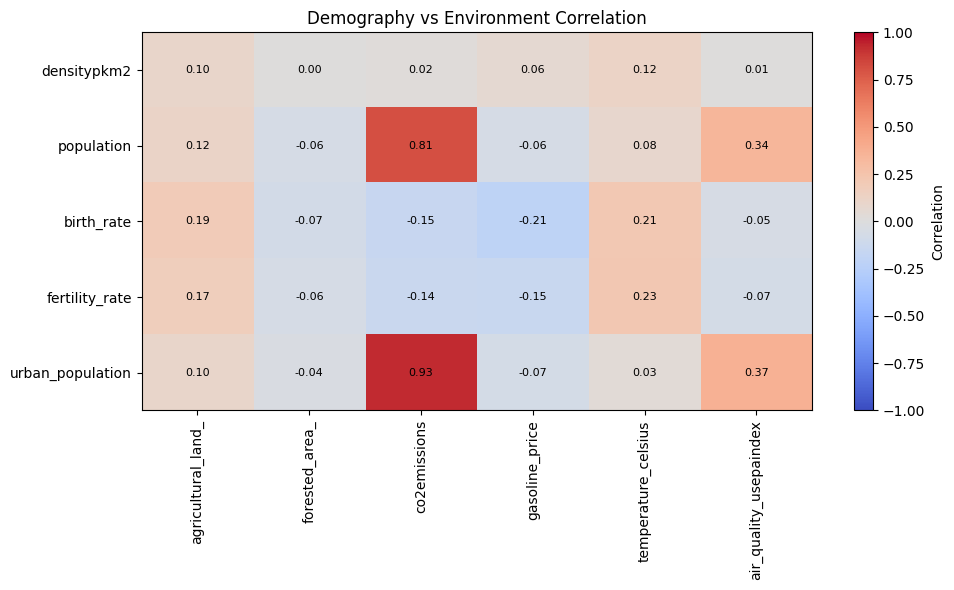


=== HEATMAP: Demography vs Geopolitics ===


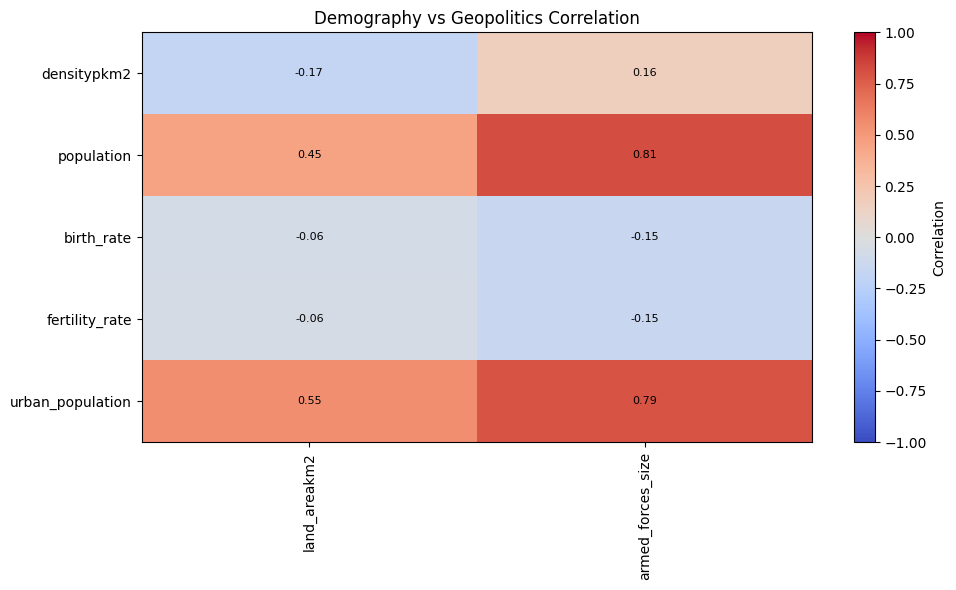


=== HEATMAP: Environment vs Geopolitics ===


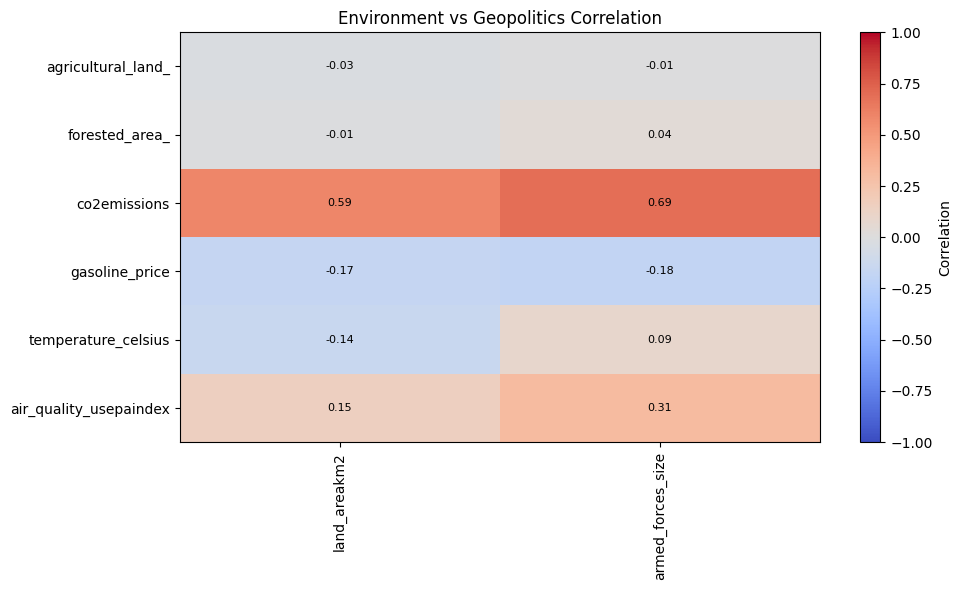

In [58]:
# Create all heatmaps across categories
for g1, g2 in itertools.combinations(categories.keys(), 2):
    corr_matrix = correlate_groups(worldwide_data, g1, g2)
    
    print(f"\n=== HEATMAP: {g1} vs {g2} ===")
    plot_heatmap(corr_matrix, f"{g1} vs {g2} Correlation")

# Final Summary of Correlation Results
### Cross-Domain Correlation Overview

| Domain Pair                   | Strength                 | Main Positive Correlations                                      | Main Negative Correlations                   |
| ----------------------------- | ------------------------ | --------------------------------------------------------------- | -------------------------------------------- |
| **Education ↔ Health**        | **Very Strong**          | Literacy ↔ Life expectancy; Tertiary enrollment ↔ Low mortality | Mortality ↔ Education                        |
| **Health ↔ Demography**       | **Strong**               | Fertility/Birth ↔ Mortality                                     | Life expectancy ↔ Fertility/Birth            |
| **Demography ↔ Environment**  | **Moderate–Strong**      | Population & Urban population ↔ CO₂ emissions                   | Minor negatives with temperature/air quality |
| **Education ↔ Environment**   | Weak                     | Small positives with forested area                              | Literacy ↔ Temperature (mild negative)       |
| **Education ↔ Geopolitics**   | Weak                     | Tertiary enrollment ↔ Armed forces size (small)                 | Almost none                                  |
| **Health ↔ Environment**      | Weak–Moderate            | Temperature ↔ Life expectancy (light positive)                  | Mortality ↔ Temperature (mild negative)      |
| **Health ↔ Geopolitics**      | Weak                     | Minor positive links with land area                             | Very small negatives                         |
| **Environment ↔ Geopolitics** | Moderate                 | CO₂ emissions ↔ Land area & Armed forces size                   | Very small negatives                         |
| **Economy ↔ Health**          | Weak                     | Tax revenue & min. wage ↔ Life expectancy                       | Minimum wage ↔ Infant mortality              |
| **Economy ↔ Education**       | Weak–Moderate            | Minimum wage ↔ Tertiary enrollment                              | CPI ↔ Literacy (mild negative)               |
| **Economy ↔ Demography**      | Moderate                 | GDP ↔ Urban population (0.78)                                   | GDP ↔ Birth rate (negative)                  |
| **Economy ↔ Environment**     | Strongest inside Economy | GDP ↔ CO₂ emissions (0.92)                                      | CPI ↔ Temperature (mild negative)            |
| **Economy ↔ Geopolitics**     | Moderate                 | GDP ↔ Armed forces size (0.56)                                  | Tax revenue ↔ Land area (negative)           |

### Highest Correlations Observed (Across All Matrices)

| Correlation   | Pair                                           |
| ------------- | ---------------------------------------------- |
| **0.92**      | GDP ↔ CO₂ emissions                            |
| **0.93**      | Urban population ↔ CO₂ emissions               |
| **0.87**      | Infant mortality ↔ Fertility rate              |
| **0.84–0.87** | Life expectancy ↔ (Birth rate, Fertility rate) |
| **0.72**      | Literacy rate ↔ Life expectancy                |
| **0.69**      | CO₂ emissions ↔ Armed forces size              |
| **0.63**      | GDP ↔ Population                               |

### Top Structural Drivers Identified

| Category        | Key Driver Variables                                  |
| --------------- | ----------------------------------------------------- |
| **Health**      | Life expectancy, Infant mortality, Maternal mortality |
| **Education**   | Literacy rate, Tertiary enrollment                    |
| **Demography**  | Fertility, Birth rate, Urban population               |
| **Environment** | CO₂ emissions                                         |
| **Economy**     | GDP (only strong cross-domain economic indicator)     |
| **Geopolitics** | Land area, Armed forces size (scale variables)        |


### Brief Interpretation

The expanded dataset confirms that **Education, Health, and Demography remain the most structurally interconnected domains**, with consistently high correlations across literacy, mortality, and fertility indicators. Environmental impact is driven primarily by **population size, urbanization, and GDP**, with CO₂ emissions emerging as one of the strongest predictors across all categories. Economic indicators such as CPI, unemployment, and tax structure maintain **weak explanatory power**, but GDP stands out as the only economic metric with strong external correlations, especially with emissions, population, and military size. Geopolitical indicators continue to function mainly as scale variables, not performance drivers.